In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Using project root:", PROJECT_ROOT)

import torch
import random
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from mask_unet.models import DebrisClassifier


Using project root: u:\users\beng\Mask_Unet


ModuleNotFoundError: No module named 'segmentation_models_pytorch'

In [ ]:
image_directory = r'U:/users/debris/data/large_trial_downsample/test'  
image_directory = os.path.join(PROJECT_ROOT, 'debris_data/test')
checkpoint_path = os.path.join(PROJECT_ROOT, "models/binary_debris_classifier.pth")


def get_transforms():
    return transforms.Compose([
        transforms.Resize((384, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet stats, modify as needed
    ])


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DebrisClassifier()
model.load_state_dict(torch.load(checkpoint_path))
model.to(device)
model.eval()


transform = get_transforms()


image_files = [f for f in os.listdir(image_directory) if f.endswith(('jpg', 'jpeg', 'png', 'tiff'))]

c:\Users\Crab_workstation\anaconda3\envs\Unet\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Crab_workstation\anaconda3\envs\Unet\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:

def display_model_predictions(image_dir, model, transform, device):
    plt.figure(figsize=(12, 12)) 
    
    image_files = os.listdir(image_dir)  # List all images in the directory
    random.shuffle(image_files)

    for i, image_name in enumerate(image_files):
        image_path = os.path.join(image_dir, image_name)
        
        image = Image.open(image_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_tensor)
            prediction = (output.squeeze() > 0.5).cpu().numpy()  # Binary prediction

        # Create a subplot to display the image and its prediction
        plt.subplot(5, 5, i + 1)  # 5x5 grid for 25 images
        plt.imshow(image)
        plt.title(f"{'Debris' if prediction == 1 else 'No Debris'}")
        plt.axis('off')

        if i == 24: 
            break  # Stop after displaying 25 images

    plt.tight_layout()
    plt.show()


In [4]:
device = torch.device("cpu")
model.to(device)
model.eval()

DebrisClassifier(
  (encoder): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

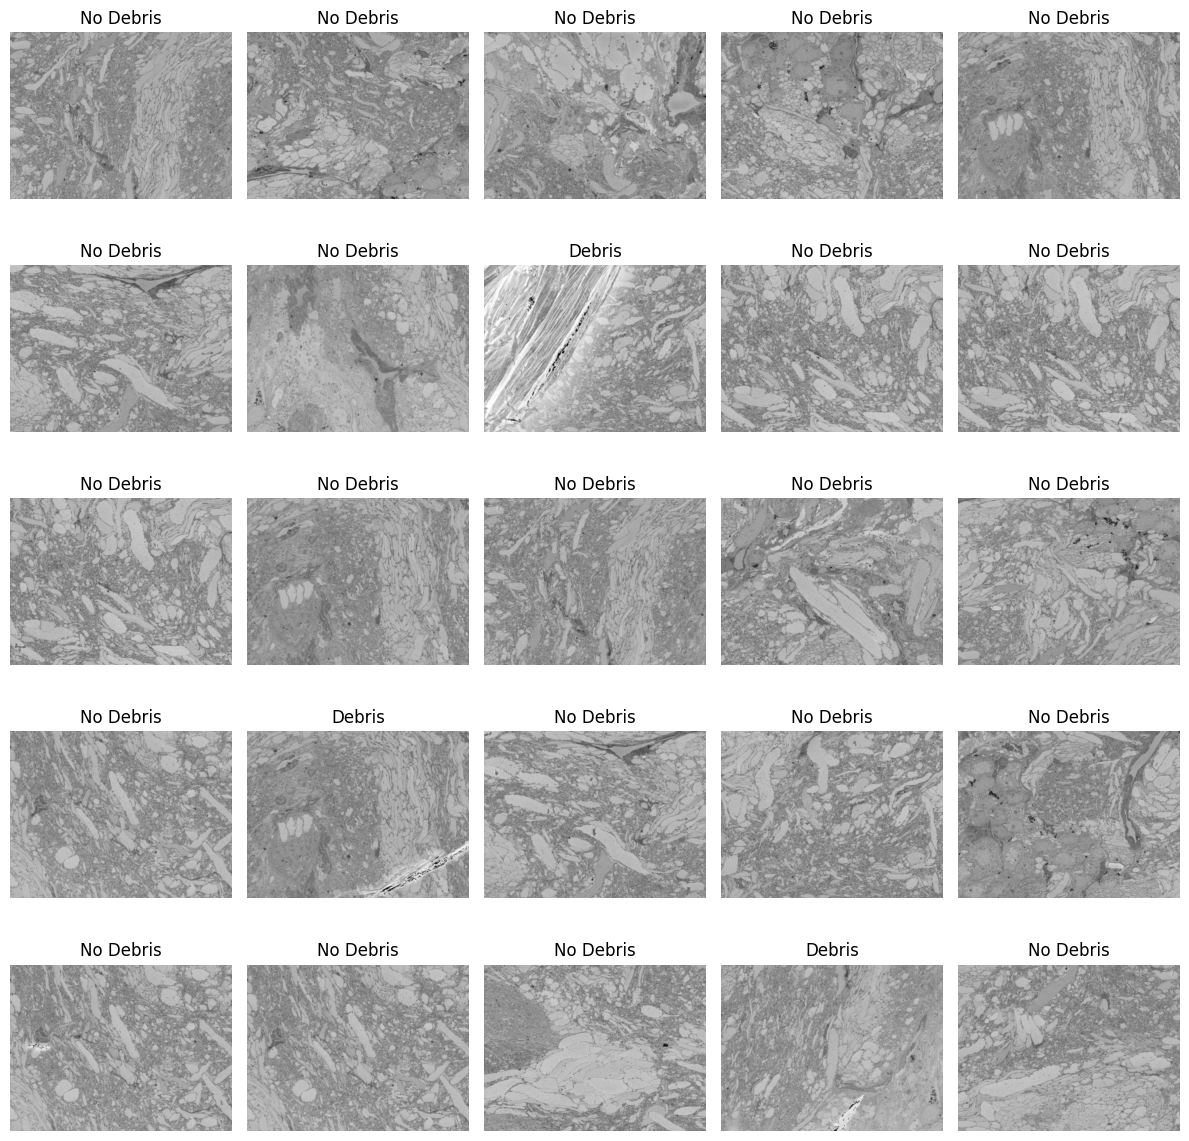

In [8]:
display_model_predictions(image_directory, model, transform, device)